In [ ]:
#Import Libraries

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try importing seaborn
try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ModuleNotFoundError:
    print("Seaborn is not installed. Continue without seaborn.")

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded successfully")

Seaborn is not installed. Continue without seaborn.
Libraries loaded successfully


In [ ]:
#Load Dataset


In [5]:
import zipfile

zip_path="amazon.csv.zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall()

df=pd.read_csv("amazon.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
# Understand Dataset


In [6]:
df.shape


(1465, 16)

In [7]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [9]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [10]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [ ]:
# Data Cleaning


In [11]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

print(df.shape)

(1465, 16)


In [13]:
num=df.select_dtypes(include=np.number)

for col in num:
    df[col].fillna(df[col].mean(),inplace=True)

In [15]:
df.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

In [ ]:
#Visualization

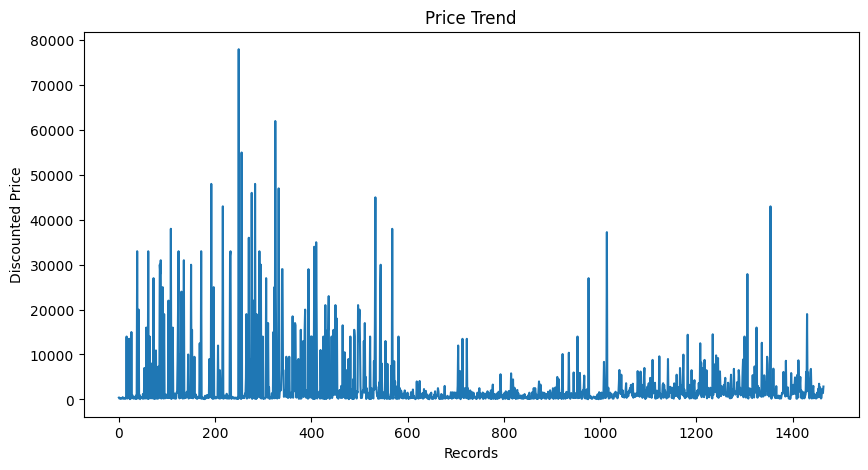

In [19]:
plt.figure(figsize=(10,5))

# Convert price column to numeric
df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

df['discounted_price'].plot()

plt.title("Price Trend")
plt.xlabel("Records")
plt.ylabel("Discounted Price")

plt.show()

In [ ]:
#Top Product

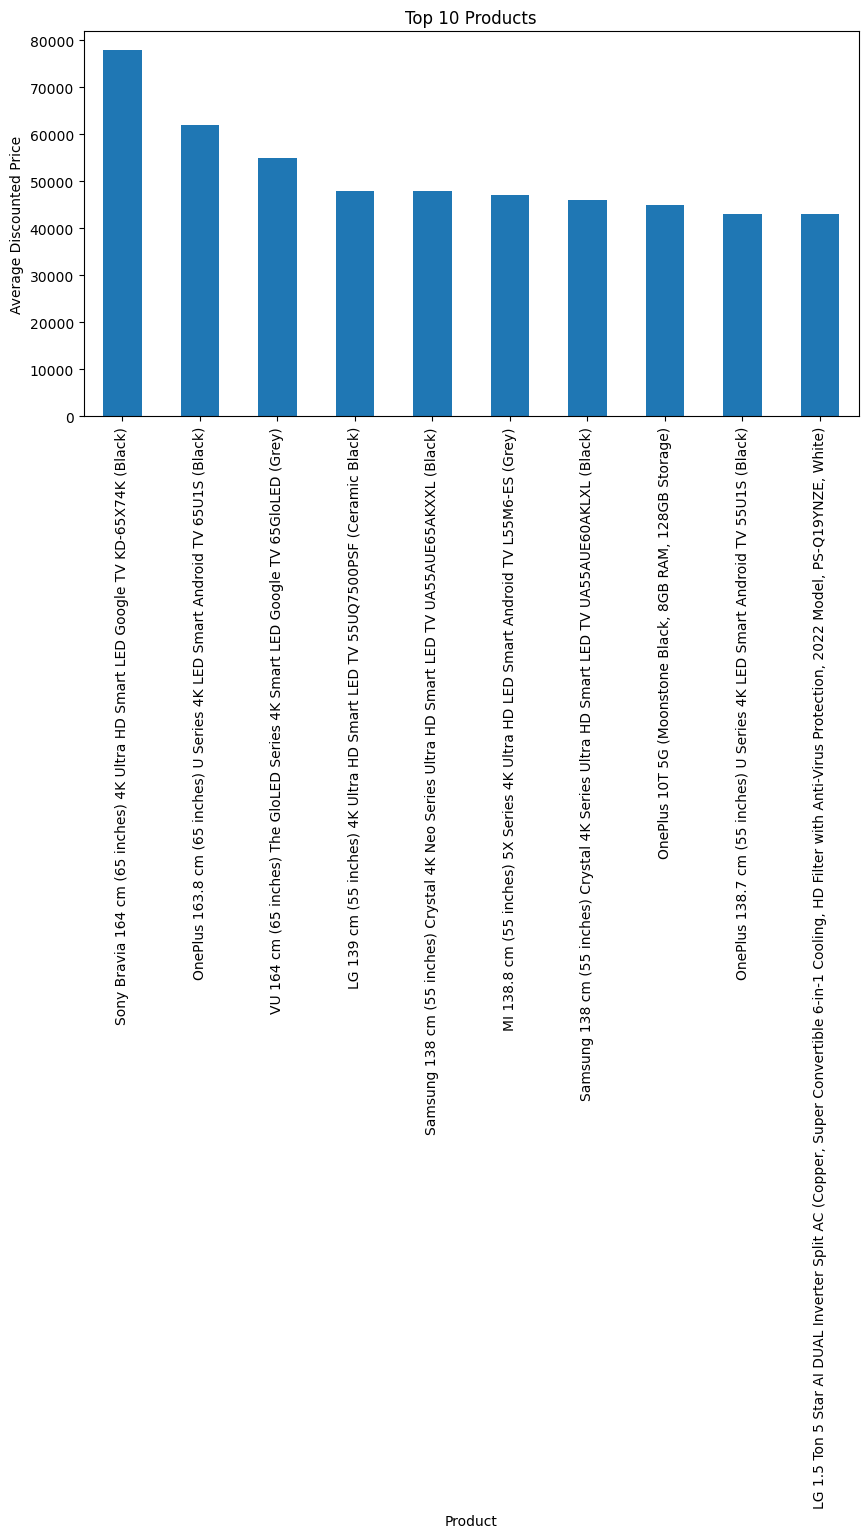

In [21]:
# Convert price into number
df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

# Top products by discounted price
top = df.groupby('product_name')['discounted_price'].mean()

top.nlargest(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Average Discounted Price")

plt.show()

In [ ]:
#Sales Distribution

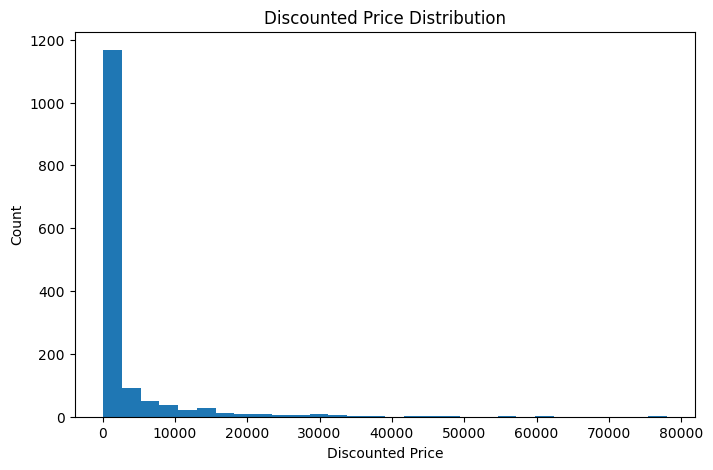

In [23]:
# Convert price to numeric

df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

# Histogram

plt.figure(figsize=(8,5))

plt.hist(
    df['discounted_price'],
    bins=30
)

plt.title("Discounted Price Distribution")
plt.xlabel("Discounted Price")
plt.ylabel("Count")

plt.show()

In [ ]:
#Heatmap

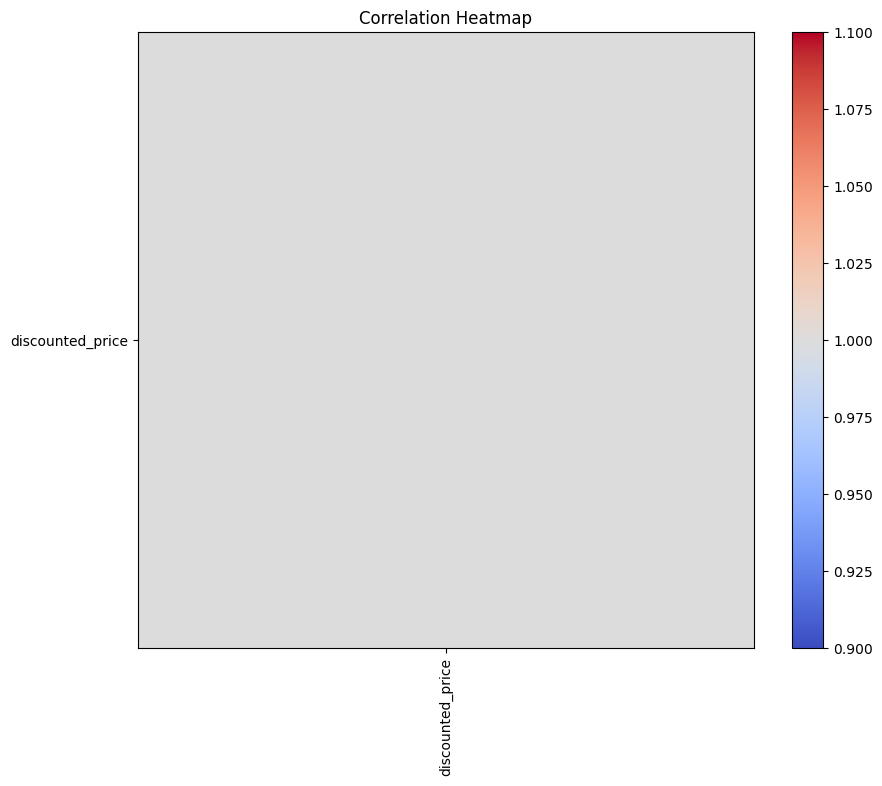

In [25]:
# Select numeric columns only
corr_matrix = df.select_dtypes(include='number').corr()

# Create heatmap using matplotlib
plt.figure(figsize=(10,8))

plt.imshow(
    corr_matrix,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#Analysis

In [27]:
# Convert discounted price into numeric

df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

# Category analysis
monthly = df.groupby(
    'category'
)['discounted_price'].mean()

print(monthly)

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    2339.000000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                    221.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                            649.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                         574.000000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                            749.000000
                                                                                                                             ...     
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens         150.000000
OfficeProducts|OfficePaperProducts|Paper|Stationery|P

In [ ]:
#Prediction Model

In [29]:
encoder=LabelEncoder()

for col in df.select_dtypes(
include='object'
):

    df[col]=encoder.fit_transform(
        df[col]
    )

In [31]:
# Convert price column to numeric

df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

# Encode text columns
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

# Features (X)
X = df.drop(
    'discounted_price',
    axis=1
)

# Target (y)
y = df['discounted_price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1465, 15)
y shape: (1465,)


In [ ]:
#trai test split

In [32]:
X_train,X_test,y_train,y_test=(
train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
)

In [33]:
model=LinearRegression()

model.fit(
X_train,
y_train
)

LinearRegression()

In [34]:
pred=model.predict(
X_test
)

print(
"MAE:",
mean_absolute_error(
y_test,
pred
)
)

print(
"R2 Score:",
r2_score(
y_test,
pred
)
)

MAE: 3582.6860573716262
R2 Score: 0.210191718744706


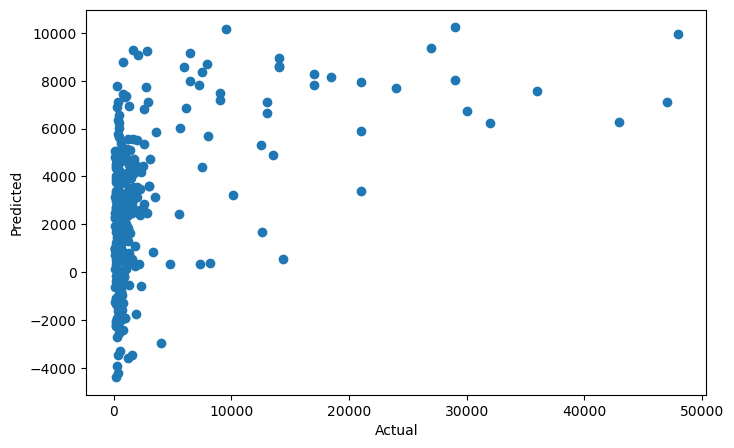

In [35]:
plt.figure(
figsize=(8,5)
)

plt.scatter(
y_test,
pred
)

plt.xlabel(
"Actual"
)

plt.ylabel(
"Predicted"
)

plt.show()

In [ ]:
# Dashboard Creation

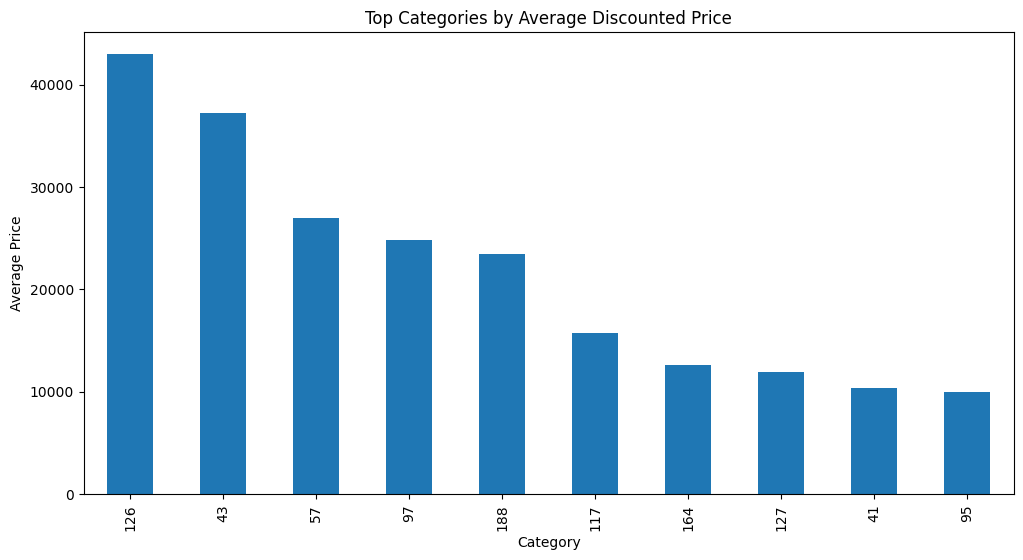

In [37]:
# Dashboard using matplotlib only

plt.figure(figsize=(12,6))

top = (
    df.groupby("category")
    ["discounted_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top.plot(
    kind="bar"
)

plt.title("Top Categories by Average Discounted Price")

plt.xlabel("Category")
plt.ylabel("Average Price")

plt.show()

   product_id  product_name  category  discounted_price  actual_price  \
0         346          1158        10             399.0             6   
1         848           134        10             199.0           258   
2         819          1023        10             199.0            65   
3         643          1264        10             329.0           379   
4         588           829        10             154.0           270   

   discount_percentage  rating  rating_count  about_product  user_id  \
0                   60      19           502            474      623   
1                   37      17           791            279       88   
2                   89      15          1010           1250      849   
3                   48      19          1129           1010      254   
4                   57      19           314           1189       17   

   user_name  review_id  review_title  review_content  img_link  product_link  
0        522        817           881           

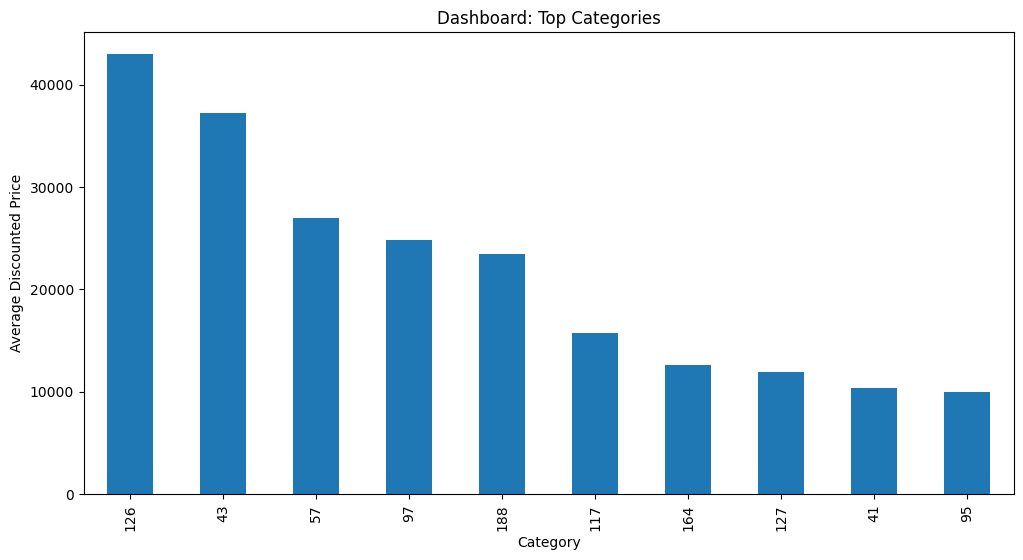

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Show first rows
print(df.head())

# Convert price column
df['discounted_price'] = (
    df['discounted_price']
    .replace('[₹,]', '', regex=True)
    .astype(float)
)

# Dashboard chart
plt.figure(figsize=(12,6))

dashboard = (
    df.groupby('category')
    ['discounted_price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

dashboard.plot(
    kind='bar'
)

plt.title("Dashboard: Top Categories")
plt.xlabel("Category")
plt.ylabel("Average Discounted Price")

plt.show()

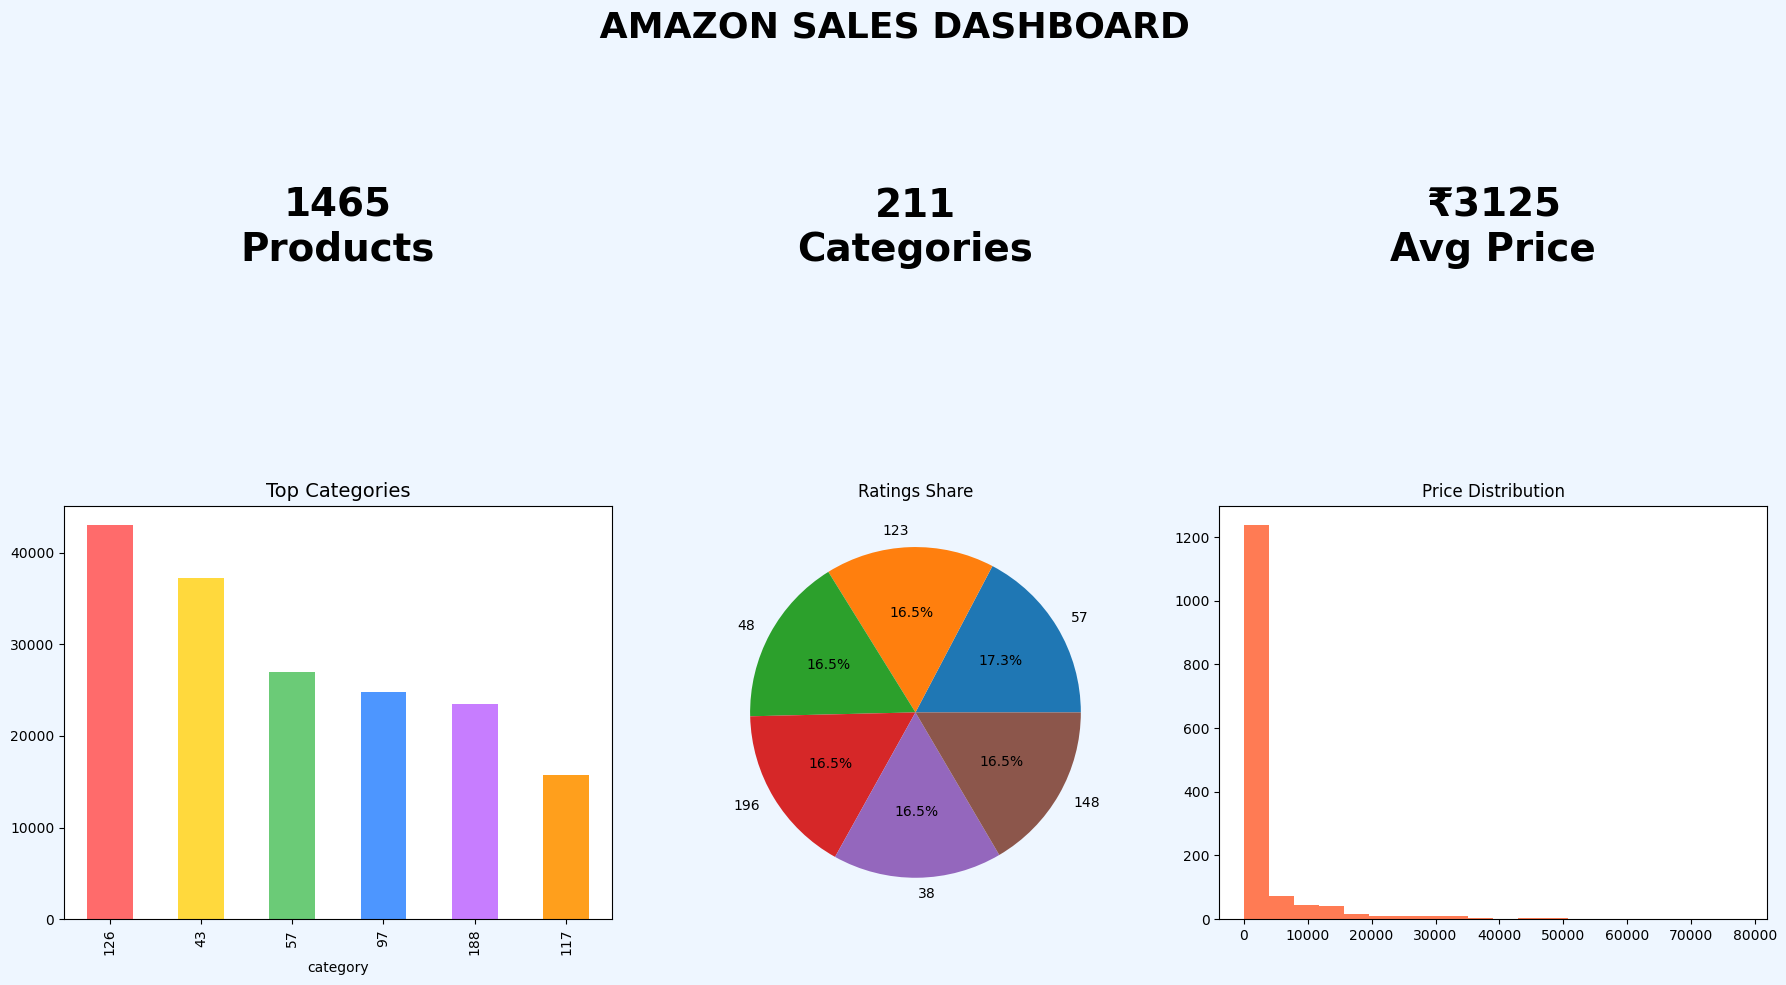

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean data
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace("₹","",regex=False)
    .str.replace(",","",regex=False)
)

df['discounted_price'] = pd.to_numeric(
    df['discounted_price'],
    errors='coerce'
)

df['rating'] = pd.to_numeric(
    df['rating'],
    errors='coerce'
)

# KPI Values
total_products = len(df)
categories = df['category'].nunique()
avg_price = round(df['discounted_price'].mean())
avg_rating = round(df['rating'].mean(),1)

top_price = (
    df.groupby("category")
    ["discounted_price"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
)

top_rating = (
    df.groupby("category")
    ["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(6)
)

# Dashboard
fig = plt.figure(
    figsize=(18,10),
    facecolor="#eef6ff"
)

fig.suptitle(
    " AMAZON SALES DASHBOARD ",
    fontsize=26,
    fontweight="bold"
)

# KPI 1
ax1=plt.subplot(2,3,1)
ax1.set_facecolor("#FFE082")
ax1.axis("off")

ax1.text(
0.5,0.5,
f"{total_products}\nProducts",
ha="center",
fontsize=28,
weight="bold"
)

# KPI 2
ax2=plt.subplot(2,3,2)
ax2.set_facecolor("#80DEEA")
ax2.axis("off")

ax2.text(
0.5,0.5,
f"{categories}\nCategories",
ha="center",
fontsize=28,
weight="bold"
)

# KPI 3
ax3=plt.subplot(2,3,3)
ax3.set_facecolor("#C5E1A5")
ax3.axis("off")

ax3.text(
0.5,0.5,
f"₹{avg_price}\nAvg Price",
ha="center",
fontsize=28,
weight="bold"
)

# Bar chart
ax4=plt.subplot(2,3,4)

top_price.plot(
kind="bar",
color=[
"#FF6B6B",
"#FFD93D",
"#6BCB77",
"#4D96FF",
"#C77DFF",
"#FF9F1C"
],
ax=ax4
)

ax4.set_title(
"Top Categories",
fontsize=14
)

# Pie chart
ax5=plt.subplot(2,3,5)

top_rating.plot(
kind="pie",
autopct="%1.1f%%",
ax=ax5
)

ax5.set_ylabel("")
ax5.set_title(
"Ratings Share"
)

# Histogram
ax6=plt.subplot(2,3,6)

ax6.hist(
df['discounted_price'],
bins=20,
color="#FF7B54"
)

ax6.set_title(
"Price Distribution"
)

plt.tight_layout()

plt.show()